In [1]:
!pip -q install insightface onnxruntime opencv-python pillow matplotlib ipywidgets > /dev/null

In [2]:
import io
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

def pil_to_bgr(pil_img: Image.Image) -> np.ndarray:
    rgb = np.array(pil_img.convert("RGB"))
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    return bgr

def draw_boxes_rgb(rgb_img: np.ndarray, boxes: np.ndarray, color=(0, 255, 0), thickness=2):
    img = rgb_img.copy()
    for b in boxes:
        x1, y1, x2, y2 = [int(v) for v in b]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img

In [3]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(name="buffalo_l", providers=["CPUExecutionProvider"])
app.prepare(ctx_id=-1, det_size=(640, 640))

print("Face detector loaded ✅")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:04<00:00, 56646.50KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Face detecto

In [4]:
def accept_or_reject_face(
    pil_img: Image.Image,
    score_thresh: float = 0.60,
    min_face_size: int = 20,
    debug: bool = False
):
    bgr = pil_to_bgr(pil_img)
    faces = app.get(bgr)

    kept = []
    kept_boxes = []
    for f in faces:
        x1, y1, x2, y2 = f.bbox
        w, h = (x2 - x1), (y2 - y1)

        if f.det_score >= score_thresh and w >= min_face_size and h >= min_face_size:
            kept.append(f)
            kept_boxes.append([x1, y1, x2, y2])

    boxes = np.array(kept_boxes) if len(kept_boxes) else np.zeros((0, 4), dtype=np.float32)
    decision = "ACCEPTED" if len(kept) > 0 else "REJECTED"

    if debug:
        print(f"Total faces detected: {len(faces)}")
        print(f"Faces kept (score>={score_thresh}, size>={min_face_size}): {len(kept)}")

    return decision, kept, boxes

In [5]:
from google.colab import files

uploaded = files.upload()
img_name = list(uploaded.keys())[0]

pil_img = Image.open(io.BytesIO(uploaded[img_name]))
print("Loaded:", img_name, "| size:", pil_img.size)

Saving Screenshot 2026-01-08 011038.png to Screenshot 2026-01-08 011038.png
Loaded: Screenshot 2026-01-08 011038.png | size: (1588, 673)


In [6]:
decision, faces_kept, boxes = accept_or_reject_face(
    pil_img,
    score_thresh=0.60,
    min_face_size=20,
    debug=True
)

print("\nFINAL OUTCOME:", decision)

Total faces detected: 0
Faces kept (score>=0.6, size>=20): 0

FINAL OUTCOME: REJECTED


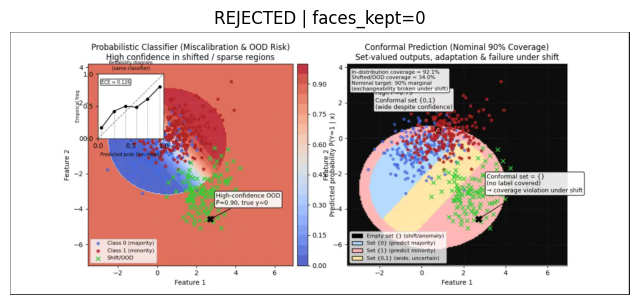

In [7]:
rgb = np.array(pil_img.convert("RGB"))
boxed = draw_boxes_rgb(rgb, boxes)

plt.figure(figsize=(8, 6))
plt.imshow(boxed)
plt.axis("off")
plt.title(f"{decision} | faces_kept={len(faces_kept)}")
plt.show()